# Experiment Plan and Baseline Alignment

This baseline is adapted to align with the architecture of Jane's CNN to ensure a fair comparison.

## 1. Experiment Plan and Expectations

First, I will train the baseline model with unrotated data, and then I will train the baseline with rotated data. It is expected that the model will perform poorly on the first setup (unrotated), but better on the second (rotated). Ultimately, the equivariant Steerable CNN model is expected to perform the best overall.

Next, I will train the Steerable CNN models. I will mostly follow Jane's code, but I have removed some unnecessary JSON configuration files and fixed a few bugs (with the help of Claude) to make the code neater and cleaner. To specifically investigate the "6 vs. 9" confusion problem, we will compare three models trained on unrotated data: a Standard CNN, a C4 Steerable CNN, and a modified C4 model restricted to the trivial group {e} at the end. A key metric we care about is the model's accuracy in distinguishing between the digits 6 and 9. It is expected that the strictly equivariant C4 model might perform worse in this regard, as it sacrifices specific orientation accuracy to remain symmetric, whereas the Standard CNN and the restricted {e} model will avoid this confusion.

Lastly, we will discuss the principles of whether we should use Steerable CNNs, what extent of symmetry is optimal, and explore a few methods that can mitigate the "6 vs. 9" problem.

---

## 2. Alignment and Modification Details

To ensure that the performance differences in the final comparison can be cleanly attributed to "equivariance" (as outlined in the plan above), the current baseline's parameters have been comprehensively adjusted. All settings are now aligned with Jane's code (C8), with the **only difference being the presence of 'equivariant constraints'**.

### 2.1 Training Settings (Fully Aligned)

| Parameter | Original Baseline | C8 Code | Current Baseline |
|---|---|---|---|
| **Dataset** | Standard MNIST | rotated MNIST (.amat) | **rotated MNIST** |
| **Train transform** | ToTensor + Normalize | pad→resize87→Rot180→resize29→ToTensor | **Identical** |
| **Test transform** | (Two sets, incl. rotated) | pad→ToTensor | **Identical** |
| **Image size** | 28×28 | 29×29 | **29×29** |
| **Batch size** | 64 | 64 | 64 (Unchanged) |
| **Epochs** | 5 | 31 | **31** |
| **Learning rate** | 1e-3 | 5e-5 | **5e-5** |
| **Weight decay** | 1e-4 | 1e-5 | **1e-5** |
| **Optimizer** | Adam | Adam | Adam (Unchanged) |

### 2.2 Architecture (Shape Aligned, Equivariant Constraints Removed)

The sequence of channel numbers, kernel sizes, padding, and downsampling locations **exactly replicate** C8's layer structure:

| Layer | Configuration |
|---|---|
| **block1** | 1 → 24, kernel=7, padding=1 |
| **block2** | 24 → 48, kernel=5, padding=2 |
| **pool1** | AvgPool stride=2 |
| **block3** | 48 → 48, kernel=5, padding=2 |
| **block4** | 48 → 96, kernel=5, padding=2 |
| **pool2** | AvgPool stride=2 |
| **block5** | 96 → 96, kernel=5, padding=2 |
| **block6** | 96 → 64, kernel=5, padding=1 |
| **pool3** | AvgPool stride=1 (5×5 → 1×1) |
| **classifier** | Linear(64,64) → BN → ELU → Linear(64,10) |

*   Replaced the original `F.layer_norm` with `BatchNorm2d` to align with C8's `InnerBatchNorm` (which is essentially BN).
*   Convolutions use `bias=False` (since they are followed by BN), consistent with C8.

### 2.3 Deliberately Unaligned Parts (Core Experimental Variable)

The only difference — **No equivariant constraints**:
*   Use `nn.Conv2d` instead of `enn.R2Conv`.
*   Remove `GeometricTensor` wrapper.
*   Remove `GroupPooling` (use spatial pooling directly).

By running both versions of the code this way, the final accuracy gap can be 100% attributed to the "presence or absence of equivariant structure", without any other confounding variables.

In [3]:
"""
MNIST CNN Baseline - trained WITHOUT rotation (self-contained version)
=======================================================================
Standalone script. Does not depend on any previous cell.

Same architecture and hyperparameters as the aligned C8 baseline, but
trained on STANDARD upright MNIST -- the model never sees a rotated
digit during training. It is then tested on both:
  1. Standard upright MNIST (sanity check, expected ~99%)
  2. Rotated MNIST (Larochelle test set, expected ~40-55%)

Expected three-way comparison across all three cells:
  - C8 SteerableCNN (equivariance + rotation training):    ~97-98% on rotated
  - CNN baseline    (rotation training only):              ~80-90% on rotated
  - CNN baseline    (no rotation in training, THIS file):  ~40-55% on rotated

How to run on Colab:
  1. Runtime -> Change runtime type -> GPU (T4 is fine)
  2. Paste this whole file into ONE cell, run it
  3. Total time: ~10 min on T4, ~3 min on A100
"""

# ============================================================
# 0. Imports + data download
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Pad, ToTensor

# Download Larochelle rotated MNIST (used only for the rotated test set)
if not os.path.exists("mnist_rotation_new"):
    print("Downloading rotated MNIST (for evaluation)...")
    os.system("wget -nc -q http://www.iro.umontreal.ca/~lisa/icml2007data/mnist_rotation_new.zip")
    os.system("unzip -nq mnist_rotation_new.zip -d mnist_rotation_new")


# ============================================================
# 1. Configuration (matches Cell 2 / C8 settings)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

BATCH_SIZE   = 64
EPOCHS       = 31
LR           = 5e-5
WEIGHT_DECAY = 1e-5


# ============================================================
# 2. Datasets
# ============================================================
class MnistRotDataset(Dataset):
    """Larochelle rotated MNIST. Used here only for the test set."""

    FILES = {
        "train": "mnist_rotation_new/mnist_all_rotation_normalized_float_train_valid.amat",
        "test":  "mnist_rotation_new/mnist_all_rotation_normalized_float_test.amat",
    }

    def __init__(self, mode, transform=None):
        assert mode in self.FILES
        self.transform = transform
        data = pd.read_csv(
            self.FILES[mode], sep=r"\s+", header=None, dtype=np.float32
        ).values
        self.images = data[:, :-1].reshape(-1, 28, 28)
        self.labels = data[:, -1].astype(np.int64)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.labels)


# ============================================================
# 3. Transforms
# ============================================================
# Pad 28x28 -> 29x29 so it fits the architecture. NO rotation.
pad      = Pad((0, 0, 1, 1), fill=0)
totensor = ToTensor()

transform = Compose([pad, totensor])


# ============================================================
# 4. Model: same architecture as the aligned baseline
# ============================================================
# Spatial size flow (input 29x29):
#   block1 (k=7, p=1):  29 -> 25
#   block2 (k=5, p=2):  25 -> 25
#   pool1  (k=5, s=2):  25 -> 13
#   block3 (k=5, p=2):  13 -> 13
#   block4 (k=5, p=2):  13 -> 13
#   pool2  (k=5, s=2):  13 ->  7
#   block5 (k=5, p=2):   7 ->  7
#   block6 (k=5, p=1):   7 ->  5
#   pool3  (k=5, s=1):   5 ->  1
# Output: (batch, 64, 1, 1) -> flatten -> Linear(64, 64) -> ... -> Linear(64, 10)
class BaselineCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=7, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(24, 48, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.AvgPool2d(kernel_size=5, stride=2, padding=2)

        self.block3 = nn.Sequential(
            nn.Conv2d(48, 48, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(48, 96, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.AvgPool2d(kernel_size=5, stride=2, padding=2)

        self.block5 = nn.Sequential(
            nn.Conv2d(96, 96, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
        )
        self.block6 = nn.Sequential(
            nn.Conv2d(96, 64, kernel_size=5, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool3 = nn.AvgPool2d(kernel_size=5, stride=1, padding=0)

        self.fully_net = nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ELU(inplace=True),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        return self.fully_net(x.reshape(x.shape[0], -1))


# ============================================================
# 5. Data loaders
# ============================================================
print("\nLoading datasets...")
# Train: standard upright MNIST
mnist_train = MNIST(root="./data", train=True,  download=True, transform=transform)
# Test set 1: standard upright MNIST (sanity check)
mnist_test_upright = MNIST(root="./data", train=False, download=True, transform=transform)
# Test set 2: rotated MNIST (the real comparison target)
mnist_test_rotated = MnistRotDataset(mode="test", transform=transform)

print(f"Train (upright): {len(mnist_train)} samples")
print(f"Test  (upright): {len(mnist_test_upright)} samples")
print(f"Test  (rotated): {len(mnist_test_rotated)} samples")

train_loader        = DataLoader(mnist_train,        batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=2, pin_memory=True)
test_loader_upright = DataLoader(mnist_test_upright, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=2, pin_memory=True)
test_loader_rotated = DataLoader(mnist_test_rotated, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=2, pin_memory=True)


# ============================================================
# 6. Model + optimizer
# ============================================================
model     = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")


# ============================================================
# 7. Train / evaluate
# ============================================================
def evaluate_on(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total   += t.size(0)
    return 100.0 * correct / total

print("\n--- Training on plain (upright) MNIST ---")
for epoch in tqdm(range(EPOCHS)):
    model.train()
    for x, t in train_loader:
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), t)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        acc_up  = evaluate_on(test_loader_upright)
        acc_rot = evaluate_on(test_loader_rotated)
        print(f"  epoch {epoch:2d} | upright: {acc_up:6.2f}% | rotated: {acc_rot:6.2f}%")


# ============================================================
# 8. Final results
# ============================================================
final_up  = evaluate_on(test_loader_upright)
final_rot = evaluate_on(test_loader_rotated)

print("\n" + "=" * 55)
print("Final results (CNN baseline, NO rotation in training)")
print("=" * 55)
print(f"  Standard (upright) MNIST test:  {final_up:6.2f}%")
print(f"  Rotated MNIST test:             {final_rot:6.2f}%")
print(f"  Accuracy drop:                  {final_up - final_rot:6.2f} pp")
print("=" * 55)


# ============================================================
# 9. Save checkpoint
# ============================================================
os.makedirs("models", exist_ok=True)
ckpt_path = "models/baseline_cnn_no_rotation.pth"
torch.save(model.state_dict(), ckpt_path)
print(f"Checkpoint saved to {ckpt_path}")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB

Loading datasets...


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


Train (upright): 60000 samples
Test  (upright): 10000 samples
Test  (rotated): 50000 samples
Model parameters: 592,466

--- Training on plain (upright) MNIST ---


  3%|▎         | 1/31 [00:11<05:30, 11.01s/it]

  epoch  0 | upright:  99.02% | rotated:  29.15%


...

 68%|██████▊   | 21/31 [02:06<01:06,  6.68s/it]

  epoch 20 | upright:  99.26% | rotated:  29.60%


100%|██████████| 31/31 [03:04<00:00,  5.95s/it]

  epoch 30 | upright:  99.38% | rotated:  31.49%



Final results (CNN baseline, NO rotation in training)
  Standard (upright) MNIST test:   99.38%
  Rotated MNIST test:              31.49%
  Accuracy drop:                   67.89 pp
Checkpoint saved to models/baseline_cnn_no_rotation.pth


In [4]:
# Cell 2: Same architecture, trained WITH rotation augmentation
# (assumes Cell 1 has been run)

import torch
from torchvision.transforms import Resize, RandomRotation, InterpolationMode

# Rotation augmentation transform -- this is the truly "new" part of Cell 2
resize_up = Resize(87)
resize_dn = Resize(29)
train_transform_rot = Compose([
    pad, resize_up,
    RandomRotation(180, interpolation=InterpolationMode.BILINEAR, expand=False),
    resize_dn, totensor,
])

# Swap training set to Larochelle rotated MNIST + the augmentation above
mnist_train_rot  = MnistRotDataset(mode="train", transform=train_transform_rot)
train_loader_rot = DataLoader(mnist_train_rot, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=(device.type == 'cuda'))

# Fresh model (same BaselineCNN class, fresh weights)
model_rot = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model_rot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

def evaluate_rot():
    model_rot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in test_loader_rotated:   # <- Reusing test loader from Cell 1
            x, t = x.to(device), t.to(device)
            pred = model_rot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total   += t.size(0)
    return 100.0 * correct / total

print("\n--- Training with rotation augmentation ---")
for epoch in tqdm(range(EPOCHS)):
    model_rot.train()
    for x, t in train_loader_rot:
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_rot(x), t)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | rotated acc: {evaluate_rot():.2f}%")

print(f"\nFinal rotated test accuracy: {evaluate_rot():.2f}%")
torch.save(model_rot.state_dict(), "models/baseline_cnn_rotation.pth")


--- Training with rotation augmentation ---


  3%|▎         | 1/31 [00:06<03:07,  6.27s/it]

  epoch  0 | rotated acc: 57.67%


 35%|███▌      | 11/31 [00:38<01:19,  3.97s/it]

  epoch 10 | rotated acc: 89.75%


 68%|██████▊   | 21/31 [01:10<00:38,  3.89s/it]

  epoch 20 | rotated acc: 92.47%


100%|██████████| 31/31 [01:43<00:00,  3.34s/it]

  epoch 30 | rotated acc: 92.46%



Final rotated test accuracy: 92.46%


In [5]:
# =============================================================================
# =====================  CELL 3  ==============================================
# =====  Setup + parameterized SteerableCNN class + C4 training run    =======
# =============================================================================

import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

# Suppress the deprecation warnings from e2cnn for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# --- install e2cnn if missing -------------------------------------------------
import subprocess, sys
try:
    import e2cnn  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn  # alias to avoid clashing with torch.nn


# --- parameterized SteerableCNN ---------------------------------------------
# Identical to Jane's C8 model, just with N as a constructor argument so we
# can sweep over C4, C8, C12, C16 by changing one number.
class CNSteerableCNN(torch.nn.Module):
    """C_N-equivariant Steerable CNN. N is the order of the cyclic group."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # block 1
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 2
        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 3
        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 4
        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 5
        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 6
        in_type  = self.block5.out_type
        out_type = enn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # group pool -> rotation-invariant features
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x); x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))


# --- reusable training function ---------------------------------------------
# Returns (trained_model, final_test_accuracy). Saves a checkpoint named
# c{N}_steerable_cnn.pth.
def train_steerable(N, epochs=EPOCHS):
    model = CNSteerableCNN(N=N).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nC{N} SteerableCNN | parameters: {n_params:,}")

    def evaluate():
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, t in test_loader_rotated:    # rotated MNIST test, from Cell 1
                x, t = x.to(device), t.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == t).sum().item()
                total   += t.size(0)
        return 100.0 * correct / total

    print(f"--- Training C{N} ---")
    for epoch in tqdm(range(epochs)):
        model.train()
        for x, t in train_loader_rot:           # rotation-augmented, from Cell 2
            x, t = x.to(device), t.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), t)
            loss.backward()
            optimizer.step()
        if epoch % 10 == 0:
            print(f"  epoch {epoch:2d} | rotated acc: {evaluate():.3f}%")

    final_acc = evaluate()
    print(f"Final C{N} accuracy: {final_acc:.3f}%")

    os.makedirs("models", exist_ok=True)
    ckpt_path = f"models/c{N}_steerable_cnn.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved to {ckpt_path}")
    return model, final_acc


# --- run the C4 experiment ---------------------------------------------------
model_c4, acc_c4 = train_steerable(N=4)



C4 SteerableCNN | parameters: 1,037,619
--- Training C4 ---


  3%|▎         | 1/31 [00:06<03:27,  6.92s/it]

  epoch  0 | rotated acc: 91.618%


 35%|███▌      | 11/31 [00:39<01:21,  4.10s/it]

  epoch 10 | rotated acc: 96.726%


 68%|██████▊   | 21/31 [01:12<00:40,  4.06s/it]

  epoch 20 | rotated acc: 97.340%


100%|██████████| 31/31 [01:45<00:00,  3.41s/it]

  epoch 30 | rotated acc: 97.548%


Final C4 accuracy: 97.548%
Saved to models/c4_steerable_cnn.pth


Evaluating Cell 2 model on rotated test set for plot...


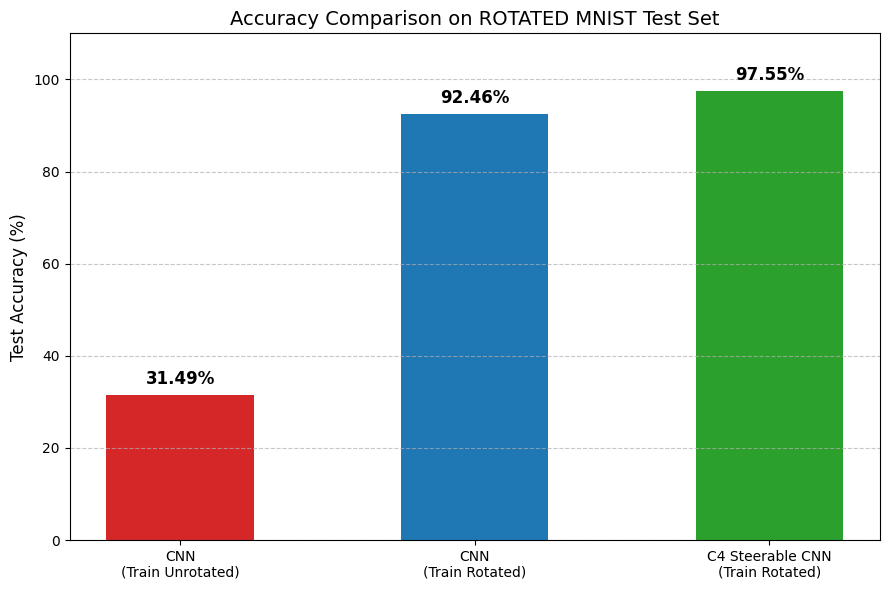

In [14]:
import matplotlib.pyplot as plt

# Get accuracies on the Rotated Test Set for the three models
# Cell 1: final_rot (CNN trained on unrotated data)
# Cell 2: evaluate_rot() (CNN trained on rotated data)
# Cell 3: acc_c4 (C4 Steerable CNN trained on rotated data)

print("Evaluating Cell 2 model on rotated test set for plot...")
acc_cnn_rot = evaluate_rot()

models = ['CNN\n(Train Unrotated)', 'CNN\n(Train Rotated)', 'C4 Steerable CNN\n(Train Rotated)']
accuracies = [final_rot, acc_cnn_rot, acc_c4]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, accuracies, color=['#d62728', '#1f77b4', '#2ca02c'], width=0.5)

plt.title('Accuracy Comparison on ROTATED MNIST Test Set', fontsize=14)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.ylim(0, 110) # Set limit slightly above 100 to leave space for labels

# Add accuracy values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

It is verified that training an ENN with rotated data performs better than a regular CNN. Next, we will investigate the 6 vs 9 problem, which means the model might behave poorly in distinguishing between 6 and 9. To better demonstrate this problem, we will train a C4 ENN on unrotated data and compare it with a normal CNN and a refined C4->{e} network.

In [6]:
# =============================================================================
# =====================  CELL 4  ==============================================
# =====  Standard CNN (Trained on Unrotated, Tested on Unrotated)       =======
# =============================================================================

print("--- Training Standard CNN on UNROTATED data ---")
model_cnn_unrot = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model_cnn_unrot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

def evaluate_cnn_unrot():
    model_cnn_unrot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in test_loader_upright:  # Unrotated test set
            x, t = x.to(device), t.to(device)
            pred = model_cnn_unrot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

for epoch in tqdm(range(EPOCHS)):
    model_cnn_unrot.train()
    for x, t in train_loader:  # Unrotated train set
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_cnn_unrot(x), t)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | unrotated test acc: {evaluate_cnn_unrot():.3f}%")

acc_cnn_unrot = evaluate_cnn_unrot()
print(f"Final Standard CNN (Unrotated) accuracy: {acc_cnn_unrot:.3f}%")

--- Training Standard CNN on UNROTATED data ---


  3%|▎         | 1/31 [00:06<03:04,  6.14s/it]

  epoch  0 | unrotated test acc: 98.840%


 35%|███▌      | 11/31 [01:00<01:53,  5.65s/it]

  epoch 10 | unrotated test acc: 99.390%


 68%|██████▊   | 21/31 [01:55<00:57,  5.74s/it]

  epoch 20 | unrotated test acc: 99.260%


100%|██████████| 31/31 [02:50<00:00,  5.51s/it]

  epoch 30 | unrotated test acc: 99.510%


Final Standard CNN (Unrotated) accuracy: 99.510%


In [7]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import e2cnn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn

class CNSteerableCNN(torch.nn.Module):
    """C_N-equivariant Steerable CNN. N is the order of the cyclic group."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # block 1
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 2
        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 3
        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 4
        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 5
        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 6
        in_type  = self.block5.out_type
        out_type = enn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # group pool -> rotation-invariant features
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x); x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))

# =============================================================================
# =====================  CELL 5  ==============================================
# =====  C4 Steerable CNN (Trained on Unrotated, Tested on Unrotated)   =======
# =============================================================================

print("--- Training C4 Steerable CNN on UNROTATED data ---")
model_c4_unrot = CNSteerableCNN(N=4).to(device)
optimizer = torch.optim.Adam(model_c4_unrot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

def evaluate_c4_unrot():
    model_c4_unrot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in test_loader_upright:  # Unrotated test set
            x, t = x.to(device), t.to(device)
            pred = model_c4_unrot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

for epoch in tqdm(range(EPOCHS)):
    model_c4_unrot.train()
    for x, t in train_loader:  # Unrotated train set
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_c4_unrot(x), t)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | unrotated test acc: {evaluate_c4_unrot():.3f}%")

acc_c4_unrot = evaluate_c4_unrot()
print(f"Final C4 Steerable CNN (Unrotated) accuracy: {acc_c4_unrot:.3f}%")


--- Training C4 Steerable CNN on UNROTATED data ---


  3%|▎         | 1/31 [00:14<07:11, 14.38s/it]

  epoch  0 | unrotated test acc: 96.940%


 35%|███▌      | 11/31 [02:29<04:36, 13.81s/it]

  epoch 10 | unrotated test acc: 97.830%


 68%|██████▊   | 21/31 [04:45<02:18, 13.80s/it]

  epoch 20 | unrotated test acc: 97.700%


100%|██████████| 31/31 [07:01<00:00, 13.58s/it]

  epoch 30 | unrotated test acc: 97.760%


Final C4 Steerable CNN (Unrotated) accuracy: 97.760%


In [8]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

# Suppress UserWarning from underlying deprecated e2cnn code
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure e2cnn is installed and imported
try:
    import e2cnn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn

class RestrictedSteerableCNN(torch.nn.Module):
    """C_N-equivariant for blocks 1-5, restricted to {e} (trivial group) for block 6."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # ===== blocks 1-5: Exactly the same as original, fully C_N equivariant =====
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        # ⬆️ Up to here, everything is C_N equivariant, identical to the original code

        # ===== Restriction point: reduce from C_N to {e} =====
        # id=1 means restricting to the trivial group containing only the identity element
        # (i.e., no rotation equivariance required)
        self.restrict = enn.RestrictionModule(out_type, id=1)
        in_type = self.restrict.out_type   # New type after restriction (in {e} gspace)

        # After restriction, the gspace changes, requiring the new gspace for subsequent FieldTypes
        small_act = in_type.gspace          # This is the gspace corresponding to {e}

        # ===== block 6: Working on {e} (mathematically equivalent to a standard convolution) =====
        out_type = enn.FieldType(small_act, 64 * [small_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # GroupPooling on {e} is a trivial operation (group has only 1 element, nothing to pool)
        # Keeping it just to maintain consistent code structure with the original
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x)
        x = self.restrict(x)         # ← Key new line: restrict to {e} here
        x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))

def train_restricted(N, epochs=EPOCHS):
    model = RestrictedSteerableCNN(N=N).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nRestricted C{N}→{{e}} | parameters: {n_params:,}")

    def evaluate(loader):
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, t in loader:
                x, t = x.to(device), t.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == t).sum().item()
                total   += t.size(0)
        return 100.0 * correct / total

    print(f"--- Training Restricted C{N}→{{e}} on UPRIGHT MNIST ---")
    for epoch in tqdm(range(epochs)):
        model.train()
        for x, t in train_loader:              # ← Changed here! Originally train_loader_rot
            x, t = x.to(device), t.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), t)
            loss.backward()
            optimizer.step()
        if epoch % 10 == 0:
            acc_up  = evaluate(test_loader_upright)
            acc_rot = evaluate(test_loader_rotated)
            print(f"  epoch {epoch:2d} | upright: {acc_up:.2f}% | rotated: {acc_rot:.2f}%")

    final_up  = evaluate(test_loader_upright)
    final_rot = evaluate(test_loader_rotated)
    print(f"\nFinal | upright: {final_up:.2f}% | rotated: {final_rot:.2f}%")

    os.makedirs("models", exist_ok=True)
    ckpt_path = f"models/c{N}_restricted_e_upright.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved to {ckpt_path}")
    return model, final_up, final_rot

# --- Run restricted C4 experiment ---
model_res, acc_up, acc_rot = train_restricted(N=4)



Restricted C4→{e} | parameters: 1,037,619
--- Training Restricted C4→{e} on UPRIGHT MNIST ---


  3%|▎         | 1/31 [00:18<09:18, 18.62s/it]

  epoch  0 | upright: 99.04% | rotated: 29.88%


 35%|███▌      | 11/31 [02:37<04:57, 14.86s/it]

  epoch 10 | upright: 99.45% | rotated: 30.98%


 68%|██████▊   | 21/31 [04:55<02:28, 14.87s/it]

  epoch 20 | upright: 99.52% | rotated: 31.34%


100%|██████████| 31/31 [07:13<00:00, 14.00s/it]

  epoch 30 | upright: 99.54% | rotated: 31.40%



Final | upright: 99.54% | rotated: 31.40%
Saved to models/c4_restricted_e_upright.pth


=== 6 vs 9 Confusion Probability on UPRIGHT Test Set ===
(Trained on Unrotated Data)

Standard CNN        :    0 / 1967 ( 0.00%)
C4 Steerable CNN    :  105 / 1967 ( 5.34%)
Restricted C4->{e}  :    0 / 1967 ( 0.00%)


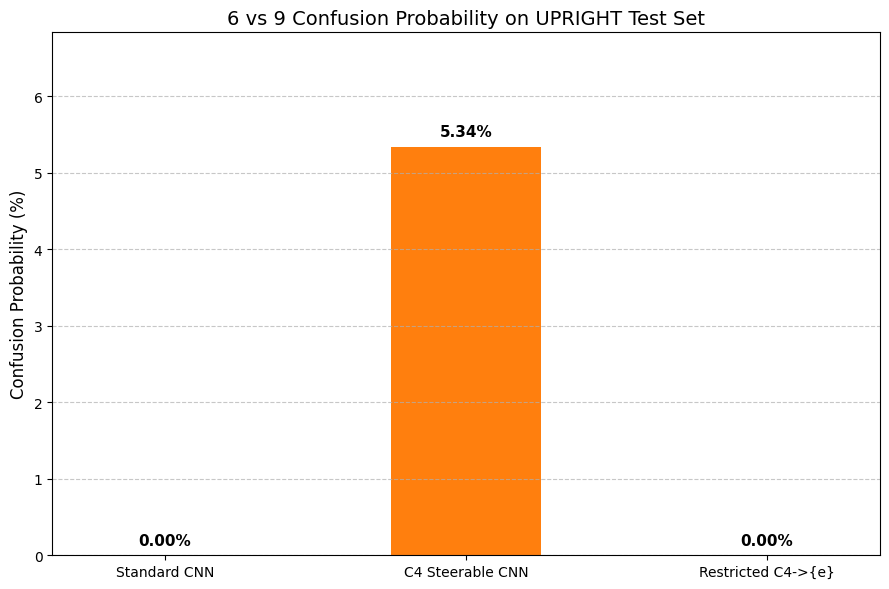

In [9]:
import matplotlib.pyplot as plt

def evaluate_69_confusion(model, loader, model_name):
    model.eval()
    confusions = 0
    total_6_and_9 = 0

    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model(x).argmax(dim=1)

            # Find samples where the true label is 6 or 9
            mask_6 = (t == 6)
            mask_9 = (t == 9)
            total_6_and_9 += (mask_6.sum() + mask_9.sum()).item()

            # Count confusions: true 6 predicted as 9, true 9 predicted as 6
            confused_6_as_9 = (mask_6 & (pred == 9)).sum().item()
            confused_9_as_6 = (mask_9 & (pred == 6)).sum().item()

            confusions += (confused_6_as_9 + confused_9_as_6)

    prob = confusions / total_6_and_9 if total_6_and_9 > 0 else 0
    print(f"{model_name:<20}: {confusions:>4} / {total_6_and_9} ({prob*100:>5.2f}%)")
    return prob * 100

print("=== 6 vs 9 Confusion Probability on UPRIGHT Test Set ===")
print("(Trained on Unrotated Data)\n")

prob_cnn = evaluate_69_confusion(model_cnn_unrot, test_loader_upright, "Standard CNN")
prob_c4  = evaluate_69_confusion(model_c4_unrot, test_loader_upright, "C4 Steerable CNN")
prob_res = evaluate_69_confusion(model_res, test_loader_upright, "Restricted C4->{e}")

# Plot the histogram (Bar Chart) for visual comparison
models = ['Standard CNN', 'C4 Steerable CNN', 'Restricted C4->{e}']
probs = [prob_cnn, prob_c4, prob_res]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, probs, color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
plt.title('6 vs 9 Confusion Probability on UPRIGHT Test Set', fontsize=14)
plt.ylabel('Confusion Probability (%)', fontsize=12)
plt.ylim(0, max(probs) + 1.5 if max(probs) > 0 else 10)

# Add probability values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
